In [49]:
import time
from os import PathLike
from pathlib import Path


import av
import torch
import torchvision
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, ConcatDataset
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.v2 as transforms
from torch.profiler import (
    profile,
    ProfilerActivity,
    record_function,
    tensorboard_trace_handler,
    schedule,
)

import torch.nn as nn
from src.utils import build_index, frame_filter
from src.read_clip import read_clip
from src.video_dataset import VideoDataset
import torch.nn as nn


%matplotlib inline
%config InlineBackend.figure_format = 'retina'

FOLDER = "./videos/train"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### 0 Подготовка данных

In [50]:
def save_videoreader_to_mp4(vreader, filename: PathLike, fps=30):
    container = av.open(str(filename), mode="w")
    stream = container.add_stream("h264", rate=fps)
    stream.pix_fmt = "yuv420p"
    for frame_dict in vreader:
        frame = frame_dict.permute(1, 2, 0).numpy()
        av_frame = av.VideoFrame.from_ndarray(frame, format="rgb24")
        for packet in stream.encode(av_frame):
            container.mux(packet)
    for packet in stream.encode():
        container.mux(packet)
    container.close()


ds = load_dataset("nateraw/kinetics-mini")
out_dir = Path(FOLDER).resolve()
out_dir.mkdir(parents=True, exist_ok=True)
for i, sample in enumerate(ds["train"]):
    video = sample["video"]
    label = sample["label"]

    label_dir = out_dir / str(label)
    label_dir.mkdir(parents=True, exist_ok=True)
    out_path = label_dir / f"video_{i:05d}.mp4"
    save_videoreader_to_mp4(video, out_path)

In [3]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x.mean()

### 1. Базовый декодер видеокадров

Реализуйте функцию чтения кадров из видео с помощью PyAV:

```python
def read_clip(filename, start=0, num_frames=16, stride=2):
    ...
```

Функция должна возвращать `numpy.ndarray` формы `(T, H, W, 3)`.
Проверьте корректность длины клипа при разных stride и выведите фактическую частоту кадров.


In [4]:
def test_read_clip(filename: PathLike):
    clip, indices, _ = read_clip(
        filename=filename, start=3, num_frames=12, stride=2, additional_info=True
    )
    true_idx = np.arange(3, 27, 2)
    assert np.all(indices == true_idx)
    assert clip.shape[0] == 12 and clip.shape[-1] == 3
    clip, indices, frame_times = read_clip(
        filename=filename, start=0, num_frames=120, stride=1, additional_info=True
    )
    true_idx = np.arange(0, 120, 1)
    assert np.all(indices == true_idx)
    assert clip.shape[0] == 120 and clip.shape[-1] == 3
    with av.open(filename) as container:
        stream = container.streams.video[0]
        fps = float(stream.average_rate)
        print(f"FPS from metadata: {fps}")
        all_times = np.array(frame_times) * float(stream.time_base)
        frame_intervals = np.diff(all_times)
        actual_fps = 1.0 / np.mean(frame_intervals)
        print("Calculated FPS:", actual_fps)

    plt.figure(figsize=(14, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(clip[0])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(clip[-1])
    plt.axis("off")

    plt.show()

FPS from metadata: 30.0
Calculated FPS: 30.0


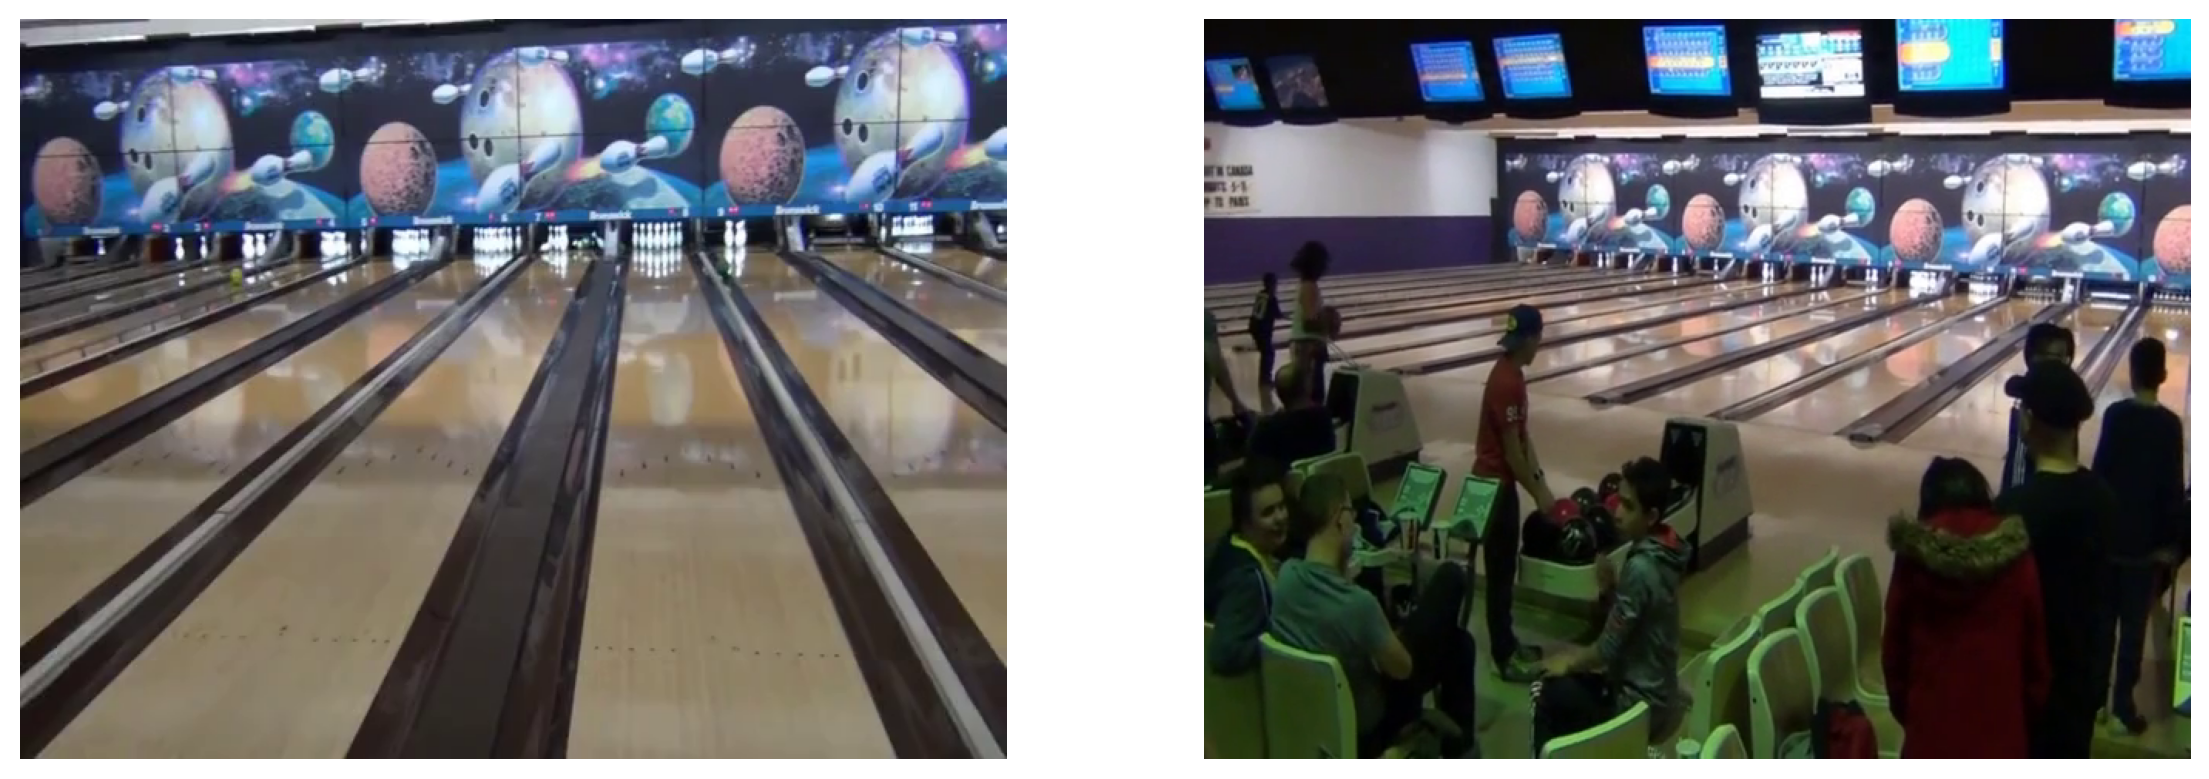

In [5]:
index = build_index(FOLDER)
test_read_clip(index[-10][0])

### 2. Реализация Dataset для видеоклипов

Создайте класс `VideoDataset`, который принимает список видеофайлов и реализует метод `__getitem__`, возвращающий один клип фиксированной длины.
Добавьте аргументы:

* `clip_len` — число кадров,
* `stride` — шаг между кадрами,
* `transform` — пайплайн препроцессинга.

Проверьте работу с `torch.utils.data.DataLoader`, задав `batch_size=4`.

In [6]:
clip_len = 60
stride = 2
filters = [frame_filter(clip_len, stride)]
index = build_index(FOLDER, filters=filters)
dataset = VideoDataset(index, clip_len, stride)
train_loader = DataLoader(dataset, batch_size=4)
start = time.monotonic()
for _ in train_loader:
    pass
end = time.monotonic() - start
print(f"time in seconds: {end:6f}")

time in seconds: 4.988762


### 3. Параллельная загрузка данных

Добавьте параметр `num_workers` в `DataLoader` и измерьте время одной эпохи при значениях `1, 2, 4, 8`.
Постройте график зависимости throughput (кадров/с) от числа потоков.
Определите, при каком `num_workers` достигается насыщение производительности.

In [7]:
from src.througput_bench import througput_bench

workers = [1, 2, 4, 8]
clip_len = 60
stride = 2
filters = [frame_filter(clip_len, stride)]
index = build_index(FOLDER, filters=filters)
dataset = VideoDataset(index, clip_len, stride)

In [8]:
througput, processing_times, _ = througput_bench(workers, dataset)

===============NUM WORKERS: 1, DATASET SIZE: 47===============
time in seconds: 6.266185
througput: 421.3090052375614
latency: 0.002373554772312866
===============NUM WORKERS: 2, DATASET SIZE: 47===============
time in seconds: 3.693446
througput: 714.7795737672874
latency: 0.0013990327042075947
===============NUM WORKERS: 4, DATASET SIZE: 47===============
time in seconds: 2.377433
througput: 1110.4413612362603
latency: 0.0009005428245996662
===============NUM WORKERS: 8, DATASET SIZE: 47===============
time in seconds: 2.115795
througput: 1247.7578771593487
latency: 0.0008014375371258762


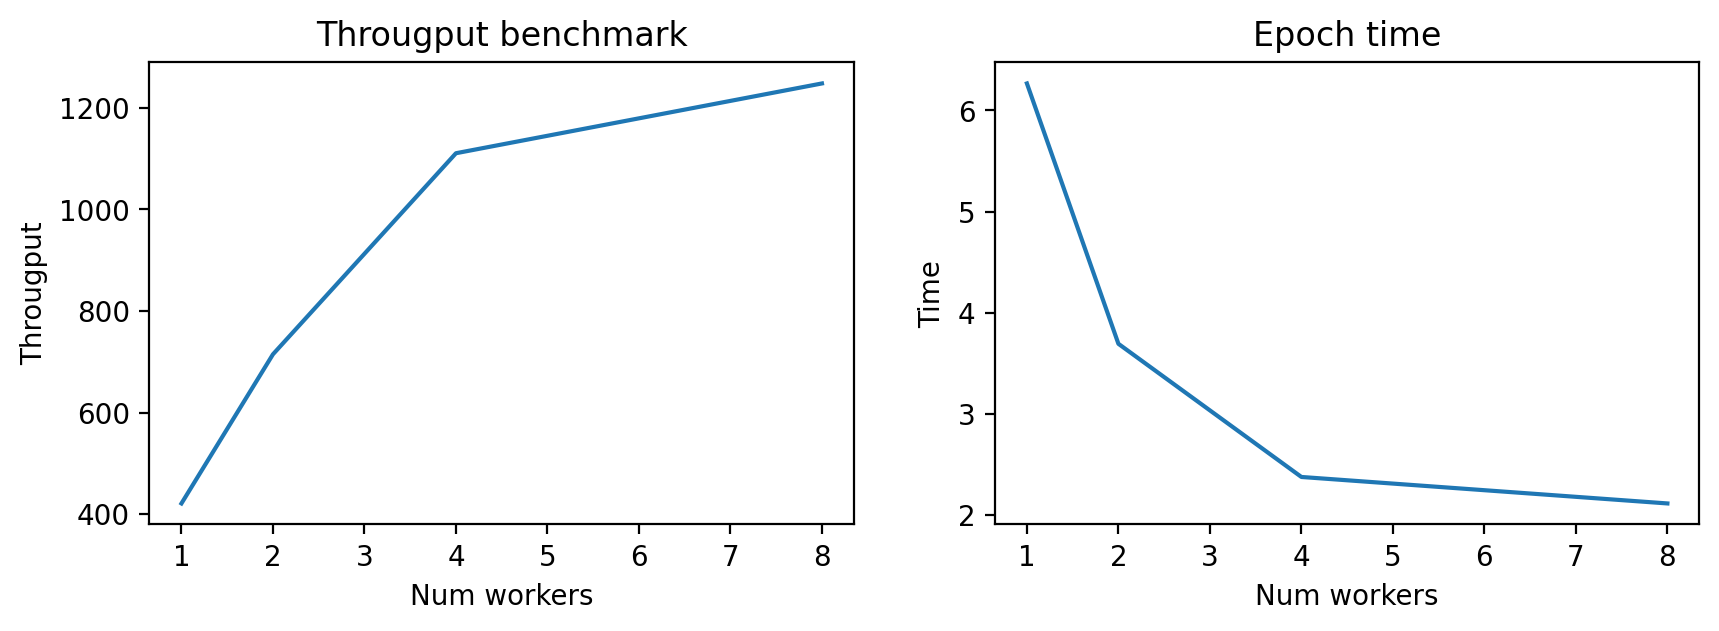

In [9]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(workers, througput)
plt.title("Througput benchmark")
plt.ylabel("Througput")
plt.xlabel("Num workers")
plt.subplot(1, 2, 2)
plt.plot(workers, processing_times)
plt.title("Epoch time")
plt.ylabel("Time")
plt.xlabel("Num workers")
plt.show()
pass

По графикам заметно, что оптимальное число процессов = 8

### 4. Профилирование этапов пайплайна

С помощью `torch.profiler` измерьте время выполнения стадий:

1. декодирования (`read_clip`);
2. препроцессинга (resize, normalize);
3. инференса (заглушка `model = lambda x: x.mean()`).

Отобразите timeline-график в TensorBoard и найдите соотношение $L_{dec}:L_{prep}:L_{inf}$.

In [10]:
def plot_stage_times(prof, title):
    events = prof.key_averages()
    stages = ["clip_decoding", "preprocessing", "model_forward"]
    times = [0.0, 0.0, 0.0]
    for event in events:
        for i, stage in enumerate(stages):
            if stage in event.key:
                time_ms = event.cpu_time / 1000.0
                if hasattr(event, "device_time") and event.device_time > 0:
                    time_ms_cuda = event.device_time / 1000.0
                    if time_ms_cuda > time_ms:
                        time_ms = time_ms_cuda
                time_ms = time_ms / event.count
                times[i] += time_ms

    plt.bar(stages, times)
    plt.title(title)
    plt.ylabel("Time (ms)")
    plt.show()

In [11]:
clip_len = 60
stride = 2
batch_size = 4
log_dir = "runs/profiling"
writer = SummaryWriter(log_dir)
filters = [frame_filter(clip_len, stride)]
index = build_index(FOLDER, filters=filters)
transform = transforms.Compose(
    [
        transforms.ToDtype(torch.float32, scale=True),
        torchvision.ops.Permute((0, 3, 1, 2)),
        transforms.Resize((112, 112)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
dataset = VideoDataset(index, clip_len, stride, transform=transform)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
    pin_memory=(DEVICE == "cuda"),
)
model = SimpleModel()

In [12]:
activities = [ProfilerActivity.CPU]
if DEVICE == "cuda":
    activities.append(ProfilerActivity.CUDA)

with profile(
    activities=activities,
    schedule=schedule(wait=1, warmup=3, active=3, repeat=1),
    on_trace_ready=tensorboard_trace_handler(log_dir),
    record_shapes=True,
    profile_memory=True,
    with_stack=True,
    with_flops=True,
) as prof:
    for batch_idx, (clip, _) in enumerate(loader):
        with record_function("inference"):
            output = model(clip)
        prof.step()

[W1225 04:25:49.677404016 CPUAllocator.cpp:245] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event


In [13]:
events = prof.key_averages()
print(events.table(sort_by="self_cpu_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          clip_decoding        53.29%        1.149s        53.29%        1.149s      95.750ms           0 B           0 B            12  
                          aten::_upsample_bilinear2d_aa        13.06%     281.598ms        13.10%     282.468ms      23.539ms     103.36 MB    -339.81 MB            12  
                                          preprocessing        12.28%     264.846ms        44.79%     965.660ms      80.472ms     103.36 MB      -2.57

In [14]:
if DEVICE == "cuda":
    print(events.table(sort_by="self_cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.01%     259.525us        99.85%        2.153s     717.642ms           4 B           0 B             3  
enumerate(DataLoader)#_SingleProcessDataLoaderIter._...         0.64%      13.757ms        99.69%        2.150s     716.511ms           0 B    -206.72 MB             3  
                                          clip_decoding        53.29%        1.149s        53.29%        1.149s      95.750ms           0 B           

In [15]:
def log_events_time(prof):
    events = prof.key_averages()
    decoding_time = 0.0
    preprocessing_time = 0.0
    inference_time = 0.0

    for event in events:
        time_ms = event.cpu_time / 1000.0
        if hasattr(event, "device_time") and event.device_time > 0:
            time_ms_cuda = event.device_time / 1000.0
            if time_ms_cuda > time_ms:
                time_ms = time_ms_cuda

        mean_time_ms = time_ms / event.count

        if event.key == "clip_decoding":
            decoding_time = mean_time_ms
        elif event.key == "preprocessing":
            preprocessing_time = mean_time_ms
        elif event.key == "inference":
            inference_time = mean_time_ms

    print(f"Decoding time (L_dec):    {decoding_time:.2f} мс")
    print(f"Preprocess time (L_prep): {preprocessing_time:.2f} мс")
    print(f"Inference time (L_inf):       {inference_time:.2f} мс")

    ratio_dec = ratio_prep = ratio_inf = 0.0
    norm_dec = norm_prep = norm_inf = 0.0
    if decoding_time > 0 and preprocessing_time > 0 and inference_time > 0:
        total = decoding_time + preprocessing_time + inference_time
        ratio_dec = decoding_time / total
        ratio_prep = preprocessing_time / total
        ratio_inf = inference_time / total

        print(
            f"\nL_dec:L_prep:L_inf = {ratio_dec:.3f}:{ratio_prep:.3f}:{ratio_inf:.3f}"
        )

        min_ratio = min(ratio_dec, ratio_prep, ratio_inf)
        norm_dec = ratio_dec / min_ratio
        norm_prep = ratio_prep / min_ratio
        norm_inf = ratio_inf / min_ratio

        print(f"Normalized ≈ {norm_dec:.1f}:{norm_prep:.1f}:{norm_inf:.1f}")
    else:
        print("\nWhoops")

    writer.add_text(
        "profiling_summary",
        f"""
    - Decoding: {decoding_time:.2f} мс
    - preprocessing: {preprocessing_time:.2f} мс 
    - Inference: {inference_time:.2f} мс

    L_dec:L_prep:L_inf = {ratio_dec:.3f}:{ratio_prep:.3f}:{ratio_inf:.3f}
    """,
    )
    writer.close()

In [16]:
log_events_time(prof)

Decoding time (L_dec):    7.98 мс
Preprocess time (L_prep): 6.71 мс
Inference time (L_inf):       0.35 мс

L_dec:L_prep:L_inf = 0.531:0.446:0.023
Normalized ≈ 22.9:19.3:1.0


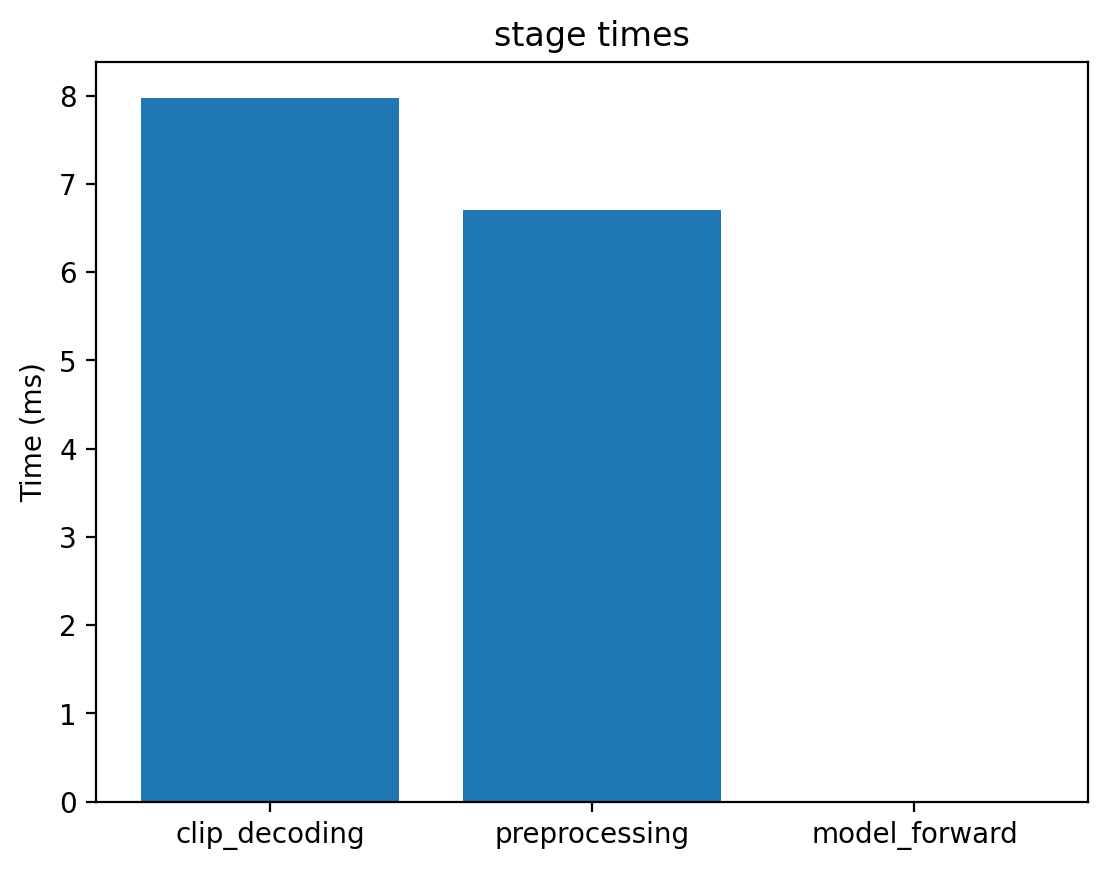

In [17]:
plot_stage_times(prof, "stage times")

По результатам видно, что наибольшее время в пайплайне занимает именно декодинг видео (при более значительной модели распределение поменяется, однако декодинг все равно будет занимать значительную часть времени)

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs/profiling

### 5. Prefetch и pinned memory

Добавьте к `DataLoader` параметры `prefetch_factor=2` и `pin_memory=True`.
Сравните средний FPS и jitter до и после включения этих опций.
Поясните, как pinned memory влияет на передачу данных между CPU и GPU.

In [19]:
def dataloader_prefetch_bench(
    dataset, prefetch_factor=None, pin_memory=False, clip_len=10
):
    train_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True,
        pin_memory=pin_memory,
        prefetch_factor=prefetch_factor,
        num_workers=4,
    )
    batch_times = []
    total_batches = 0
    model = SimpleModel()

    for clip, *_ in train_loader:
        batch_start = time.time()
        clip = clip.to("cuda", non_blocking=True)
        model(clip)
        torch.cuda.synchronize()
        batch_end = time.time()
        batch_time = batch_end - batch_start
        batch_times.append(batch_time)
        total_batches += 1

    fps_values = [clip_len * batch_size / t for t in batch_times]
    avg_fps = sum(fps_values) / len(fps_values)
    avg_time_per_batch = sum(batch_times) / len(batch_times)

    jitter = np.std(batch_times)
    return {
        "avg_fps": avg_fps,
        "avg_time_per_batch": avg_time_per_batch,
        "jitter": jitter,
        "batch_times": batch_times,
        "prefetch_factor": prefetch_factor,
        "pin_memory": pin_memory,
    }

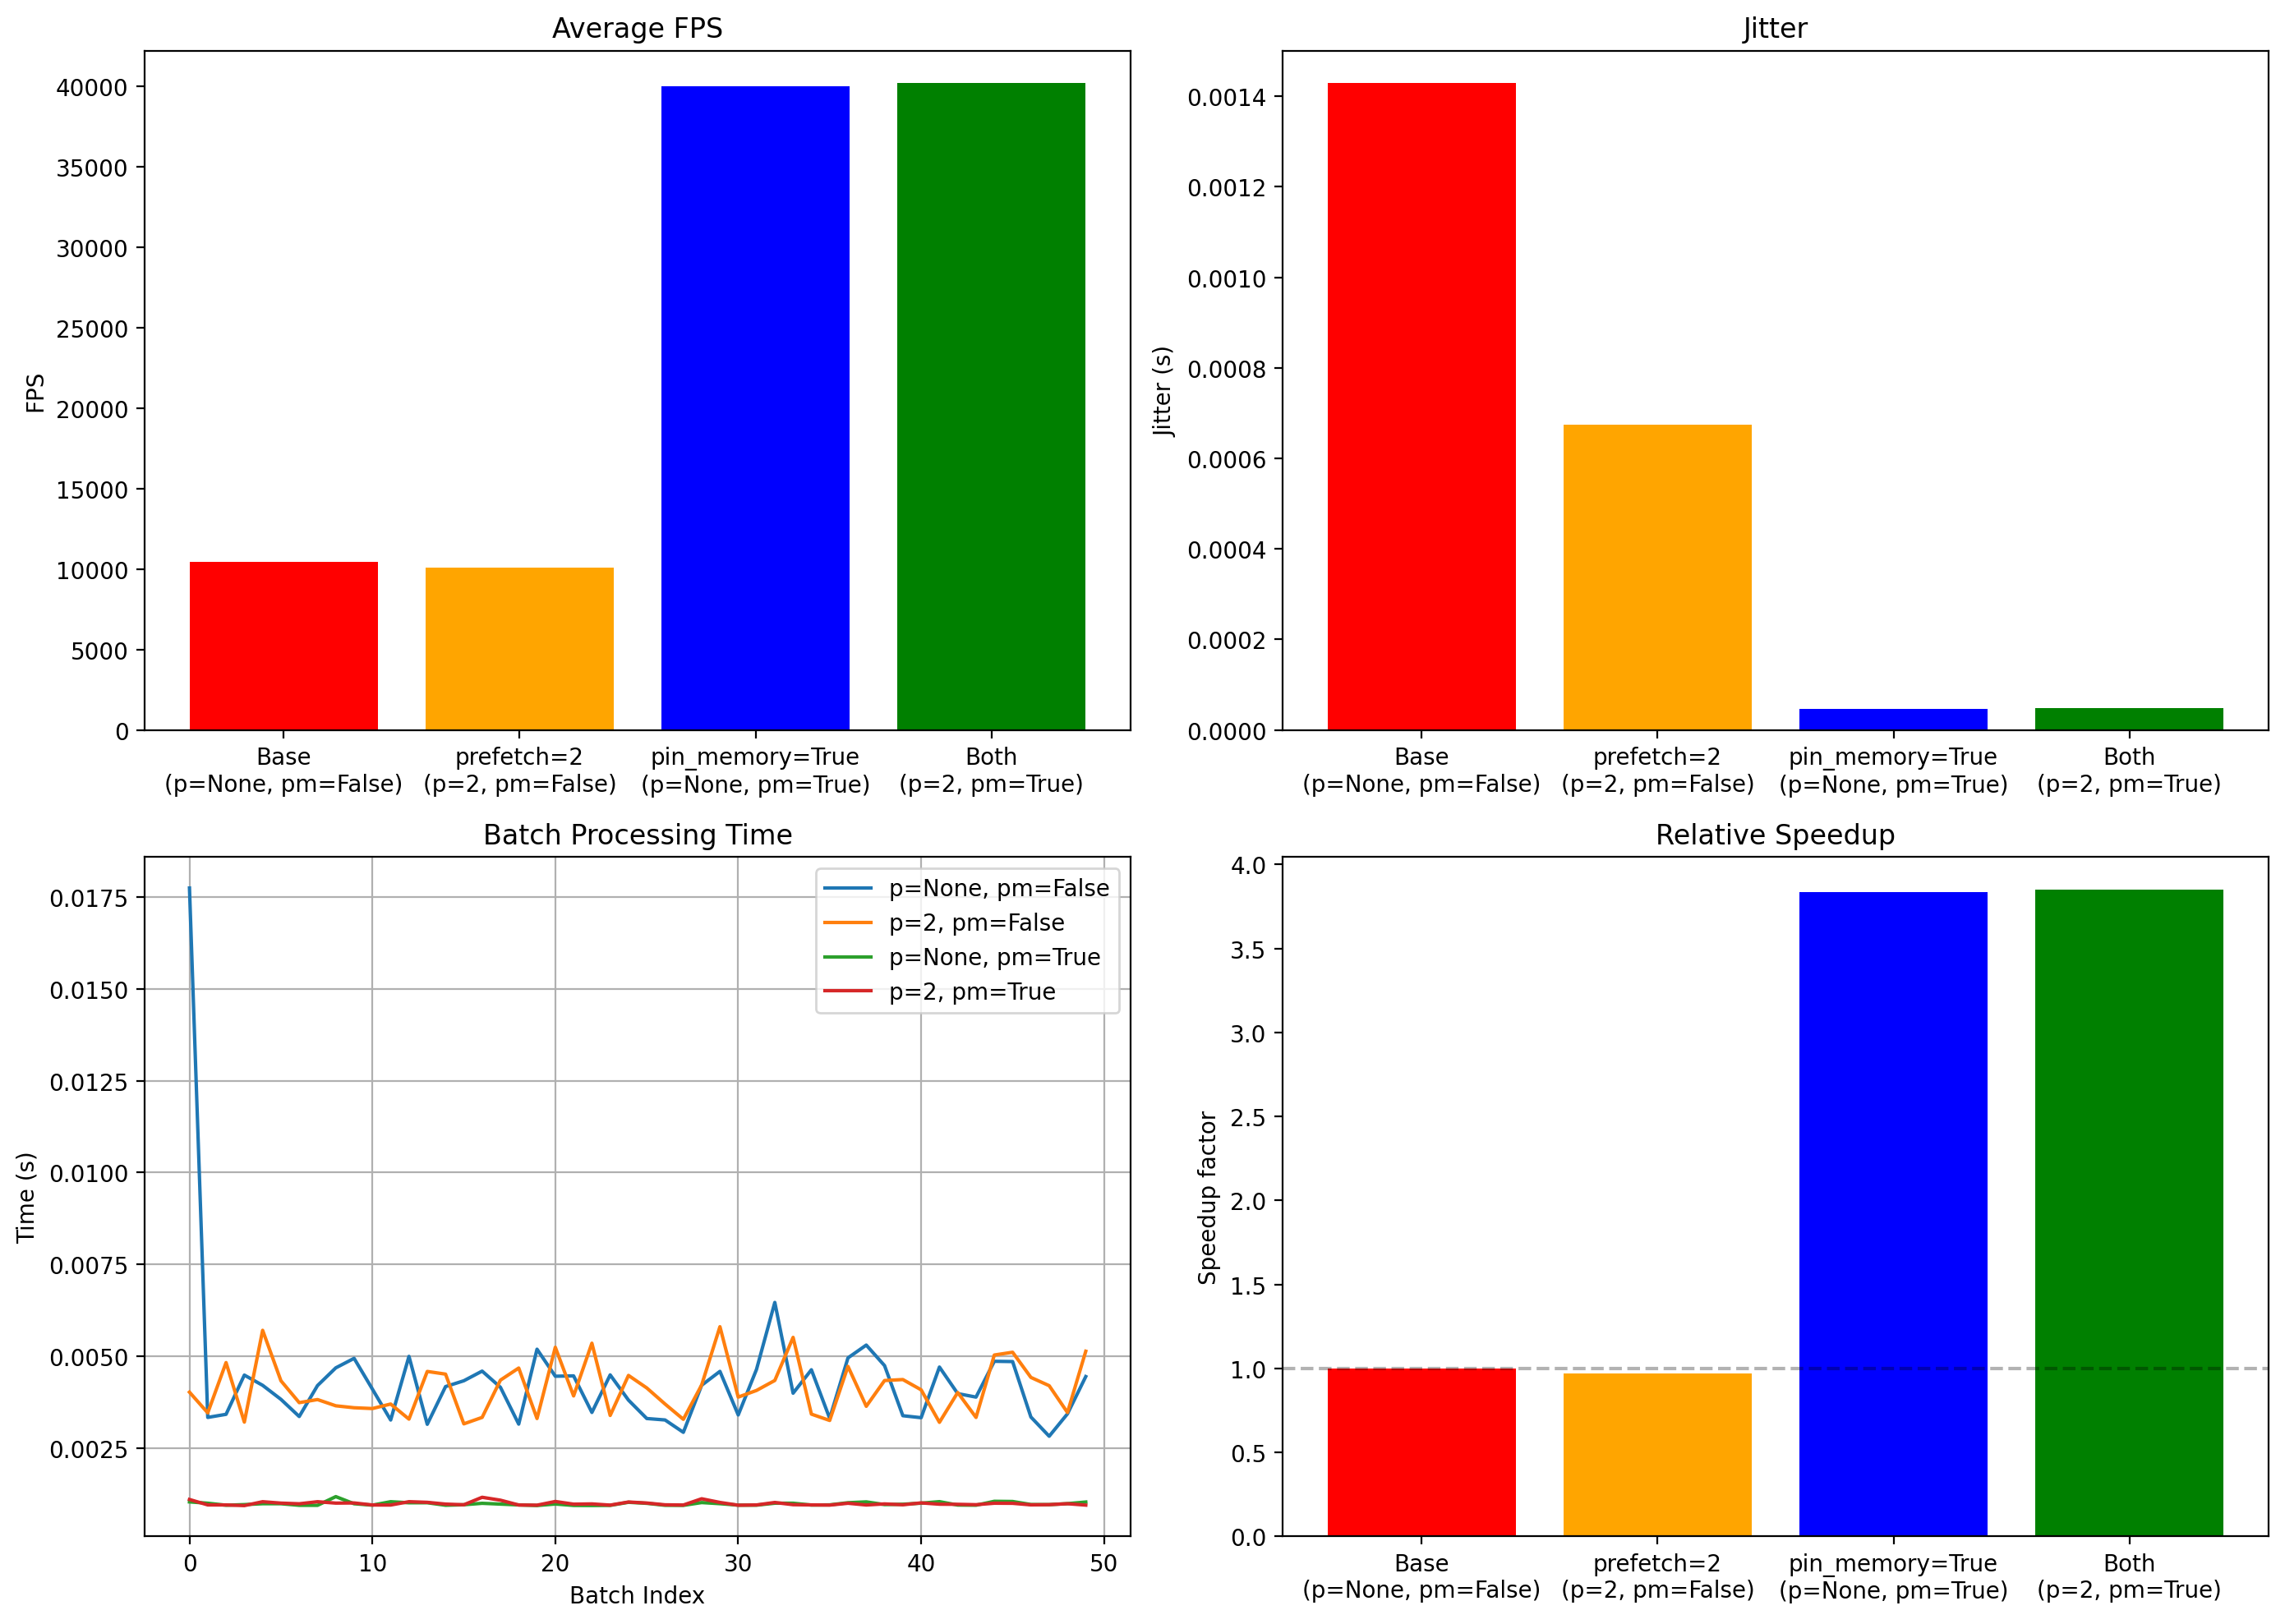

In [20]:
if DEVICE == "cuda":
    clip_len = 10
    stride = 2
    filters = [frame_filter(clip_len, stride)]
    index = build_index(FOLDER, filters=filters)
    dataset = ConcatDataset(
        [VideoDataset(index, clip_len, stride, transform=transform)] * 10
    )
    results = []
    results.append(
        dataloader_prefetch_bench(
            dataset, prefetch_factor=None, pin_memory=False, clip_len=clip_len
        )
    )
    results.append(
        dataloader_prefetch_bench(
            dataset, prefetch_factor=2, pin_memory=False, clip_len=clip_len
        )
    )
    results.append(
        dataloader_prefetch_bench(
            dataset, prefetch_factor=None, pin_memory=True, clip_len=clip_len
        )
    )
    results.append(
        dataloader_prefetch_bench(
            dataset, prefetch_factor=2, pin_memory=True, clip_len=clip_len
        )
    )

    fps_values = [r["avg_fps"] for r in results]
    configs = [
        "Base\n(p=None, pm=False)",
        "prefetch=2\n(p=2, pm=False)",
        "pin_memory=True\n(p=None, pm=True)",
        "Both\n(p=2, pm=True)",
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    # 1. Average FPS
    fps_values = [r["avg_fps"] for r in results]
    axes[0].bar(configs, fps_values, color=["red", "orange", "blue", "green"])
    axes[0].set_title("Average FPS")
    axes[0].set_ylabel("FPS")

    # 2. Jitter
    jitter_values = [r["jitter"] for r in results]
    axes[1].bar(configs, jitter_values, color=["red", "orange", "blue", "green"])
    axes[1].set_title("Jitter")
    axes[1].set_ylabel("Jitter (s)")

    # 3. Batch processing times
    for i, result in enumerate(results):
        batch_times = result["batch_times"][:50]
        axes[2].plot(
            batch_times,
            label=f"p={result['prefetch_factor']}, pm={result['pin_memory']}",
        )
    axes[2].set_title("Batch Processing Time")
    axes[2].set_xlabel("Batch Index")
    axes[2].set_ylabel("Time (s)")
    axes[2].legend()
    axes[2].grid(True)

    # 4. Relative speedup
    base_fps = results[0]["avg_fps"]
    speedups = [r["avg_fps"] / base_fps for r in results]
    axes[3].bar(configs, speedups, color=["red", "orange", "blue", "green"])
    axes[3].axhline(y=1.0, color="black", linestyle="--", alpha=0.3)
    axes[3].set_title("Relative Speedup")
    axes[3].set_ylabel("Speedup factor")

    plt.tight_layout()
    plt.show()

pin_memory фиксирует данные в специальной области RAM из которой после возможно произвести быструю передачу данных с хоста на девайс. Как видно по графикам pin_memory значительно превосходит обычную загрузку данных при работе с gpu.

Чаще всего prefetch_factor все таки повышает средний fps за счет более хорошего перекрытия времени подгрузки.

### 6. Pipeline overlap

Модифицируйте код так, чтобы декодирование и инференс выполнялись в разных потоках.
Используйте `torch.cuda.Stream` и `multiprocessing.Queue`.
Измерьте разницу в среднем latency между последовательным и перекрытым исполнением.

Код запускается как скрипт, поскольку у jupyter есть проблемы с запуском процессов через spawn

**Предобработка на cpu и inference на cpu**

In [41]:
!python -m src.paralel_pipeline --folder videos

Processing batch...
Processed 49 clips
Mean latency: 0.1180s
Pipeline throughput: 6.51 clips/sec
Mean FPS: 195.44057873188044
Jitter: 0.0502922366084828


**Предобработка на cuda и inference на cuda**

In [38]:
!python -m src.paralel_pipeline --folder videos --device cuda

Processing batch...
Processed 49 clips
Mean latency: 0.0993s
Pipeline throughput: 8.65 clips/sec
Mean FPS: 341.059068608371
Jitter: 0.042676307271755046


**Предобработка на cuda и inference на cuda**

In [39]:
!python -m src.paralel_pipeline --folder videos --device cuda --decoder decord

Processing batch...
Processed 49 clips
Mean latency: 0.0908s
Pipeline throughput: 9.60 clips/sec
Mean FPS: 351.9231446407382
Jitter: 0.02565834326844104


**Предобработка на cpu и inference на cuda**

In [40]:
!python -m src.paralel_pipeline --folder videos --device cuda --decoder decord --cuda-transform false

Processing batch...
Processed 49 clips
Mean latency: 0.0878s
Pipeline throughput: 9.99 clips/sec
Mean FPS: 359.79312368846536
Jitter: 0.024907958986538477


Видно что препроцессинг на cuda и инференс на cuda показывает себя лучше. throughput повысился на 60% со всеми оптимизациями.

Jitter считался по latency.

Latency оценивалась как задержка от поступления декодированного клипа в очередь до окончания его обработки.

**Важное замечание** Для подсчета fps использовалось полное время пайплайна, т.е не мгновенный fps на выходе из очереди.

### 7. Аппаратное декодирование

Если доступна GPU с поддержкой NVDEC, используйте `decord.VideoReader` с `ctx=decord.gpu(0)`.
Сравните время декодирования для PyAV (CPU) и decord (GPU).
Выведите таблицу:

| Метод | Среднее время декодирования (мс) | FPS |
| ----- | -------------------------------- | --- |

In [29]:
import pandas as pd
from src.read_clip import read_clip_decord

clip_len = 60
stride = 2
filters = [frame_filter(clip_len, stride)]
index = build_index(FOLDER, filters=filters)

decode_func = [read_clip, read_clip_decord]
res = {fn.__name__: [] for fn in decode_func}
for fn in decode_func:
    for clip_path, _ in index:
        t0 = time.monotonic()
        fn(clip_path, 0, clip_len, stride)
        res[fn.__name__].append(time.monotonic() - t0)

pd_res = {
    "Метод": [name for name in res],
    "Среднее время декодирования (мс)": [np.mean(val) for val in res.values()],
    "FPS": [clip_len / np.sum(val) for val in res.values()],
}
pd_res = pd.DataFrame(pd_res)
print(pd_res)

              Метод  Среднее время декодирования (мс)        FPS
0         read_clip                          0.070858  18.016292
1  read_clip_decord                          0.074099  17.228225


**Замечание:** Использовался decord с cpu контекстом, поскольку нет возможности собрать decord из исходников. Но decord часто и c cpu контекстом дает больше fps.

### 8. Оптимизация препроцессинга

Реализуйте вариант препроцессинга на GPU через `torchvision.transforms.v2`.
Сравните общую латентность с вариантом на CPU.
Постройте столбчатую диаграмму времени на этапах decode / transform / infer.


In [31]:
clip_len = 60
stride = 2
batch_size = 4
log_dir = "runs/profiling"
writer = SummaryWriter(log_dir)
filters = [frame_filter(clip_len, stride)]
index = build_index(FOLDER, filters=filters)


def get_transforms(device):
    return transforms.Compose(
        [
            transforms.ToDtype(torch.float32, scale=True),
            torchvision.ops.Permute((0, 1, 4, 2, 3)),
            transforms.Resize((112, 112)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    ).to(device)


dataset = VideoDataset(index, clip_len, stride)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

if DEVICE == "cuda":
    activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    with profile(
        activities=activities,
        on_trace_ready=tensorboard_trace_handler(log_dir),
        schedule=schedule(wait=1, warmup=3, active=3, repeat=1),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
        with_flops=True,
    ) as cuda_process_profile:
        dataset = VideoDataset(index, clip_len, stride)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            drop_last=True,
        )
        transform = get_transforms("cuda")
        model = SimpleModel().to("cuda")
        for batch_idx, (clip, _) in enumerate(loader):
            clip = clip.to("cuda")
            with record_function("preprocessing"):
                clip = transform(clip)
            with record_function("inference"):
                _ = model(clip)
            torch.cuda.synchronize()
            cuda_process_profile.step()

    with profile(
        activities=activities,
        on_trace_ready=tensorboard_trace_handler(log_dir),
        schedule=schedule(wait=1, warmup=3, active=3, repeat=1),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
        with_flops=True,
    ) as cpu_process_profile:
        dataset = VideoDataset(index, clip_len, stride)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            drop_last=True,
        )
        transform = get_transforms("cpu")
        model = SimpleModel().to("cuda")
        for batch_idx, (clip, _) in enumerate(loader):
            with record_function("preprocessing"):
                clip = transform(clip)
            clip = clip.to("cuda")
            with record_function("inference"):
                _ = model(clip)
            torch.cuda.synchronize()
            cpu_process_profile.step()

    print("=" * 10 + "CUDA preprocessing" + "=" * 10)
    log_events_time(cuda_process_profile)
    print("=" * 10 + "CPU preprocessing" + "=" * 10)
    log_events_time(cpu_process_profile)

==========CUDA preprocessing==========
Decoding time (L_dec):    7.63 мс
Preprocess time (L_prep): 0.21 мс
Inference time (L_inf):       0.03 мс

L_dec:L_prep:L_inf = 0.969:0.026:0.004
Normalized ≈ 221.1:6.0:1.0
==========CPU preprocessing==========
Decoding time (L_dec):    7.59 мс
Preprocess time (L_prep): 3.76 мс
Inference time (L_inf):       0.03 мс

L_dec:L_prep:L_inf = 0.667:0.330:0.003
Normalized ≈ 244.0:120.9:1.0


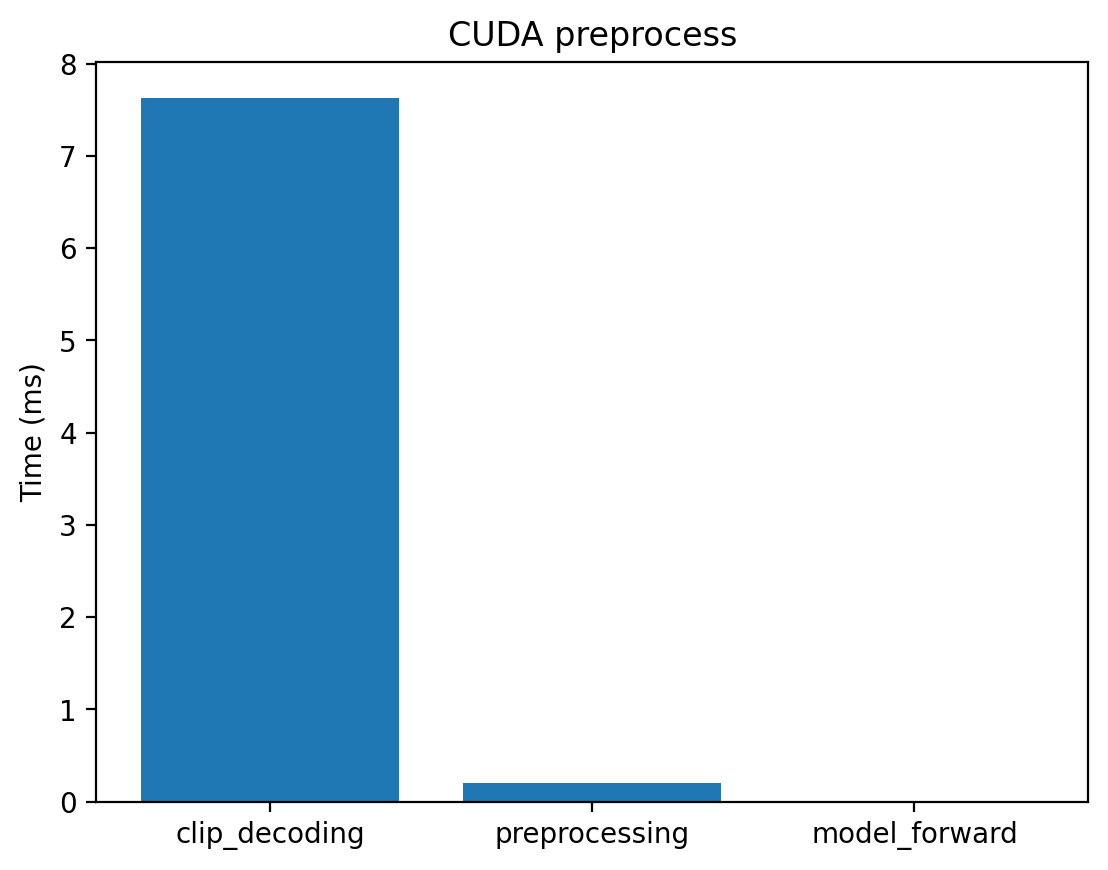

In [32]:
plot_stage_times(cuda_process_profile, "CUDA preprocess")

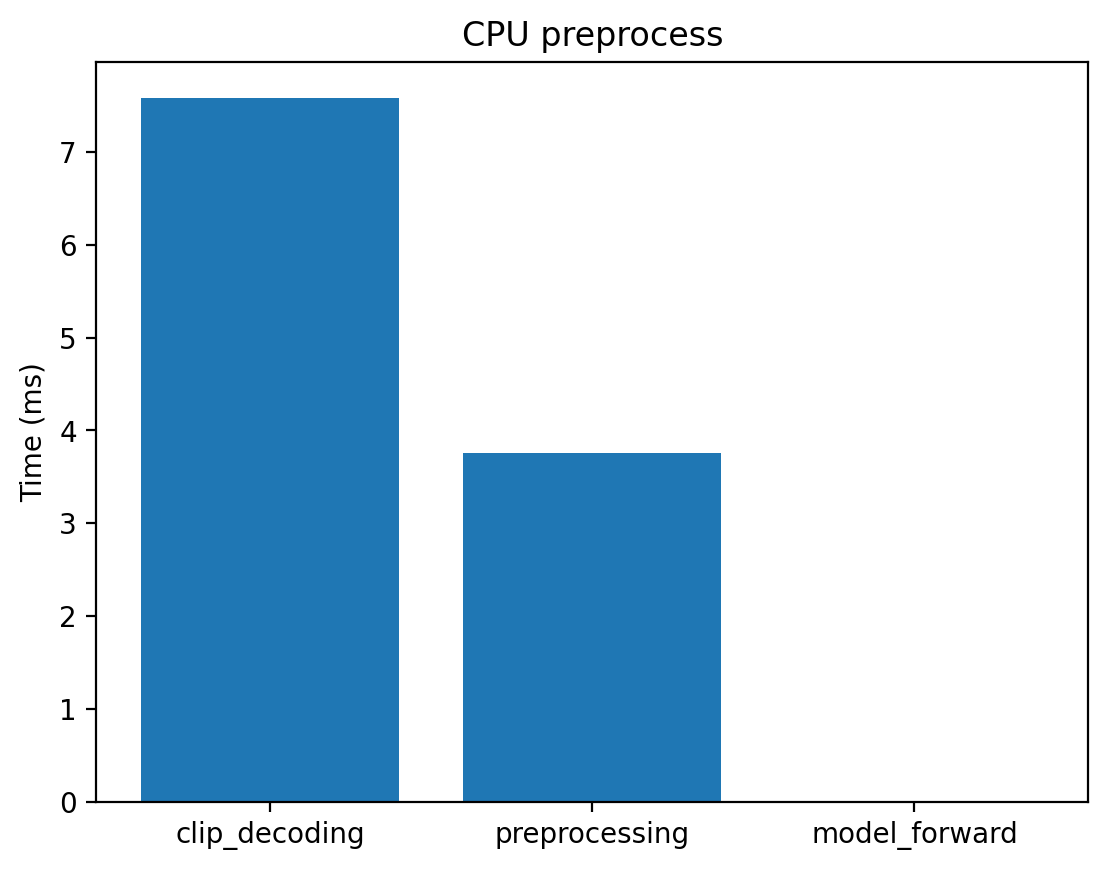

In [33]:
plot_stage_times(cpu_process_profile, "CPU preprocess")

###  9. Измерение стабильности FPS
Добавьте измерение мгновенного FPS и коэффициента вариации:
$$
CV = \frac{\sigma_{FPS}}{\mu_{FPS}}.
$$

Запишите значения FPS за 100 итераций и постройте график.
Определите, при каком размере батча и глубине очереди FPS становится стабильным ($CV < 0.05$).

In [47]:
!python -m src.paralel_pipeline \
  --folder videos \
  --device cuda \
  --decoder decord \
  --benchmark


Running benchmark: batch=1, queue=8
Processing batch...

Running benchmark: batch=1, queue=16
Processing batch...

Running benchmark: batch=1, queue=32
Processing batch...

Running benchmark: batch=2, queue=8
Processing batch...

Running benchmark: batch=2, queue=16
Processing batch...

Running benchmark: batch=2, queue=32
Processing batch...

Running benchmark: batch=8, queue=8
Processing batch...

Running benchmark: batch=8, queue=16
Processing batch...

Running benchmark: batch=8, queue=32
Processing batch...
==========FPS Stability Benchmark ==============================
 batch_size  queue_size   mean_fps   std_fps       cv  stable
          1           8 250.645115 78.587613 0.313541   False
          1          16 268.040449 74.628643 0.278423   False
          1          32 273.416089 82.754184 0.302668   False
          2           8 344.960352 69.651990 0.201913   False
          2          16 350.177132 62.579732 0.178709   False
          2          32 354.968643 69.741362

**Важное замечание** Для подсчета fps использовался мгновенный фпс на отрезке от попадания в очередь ожидания до полной обработки.

### 10. Мини-RT пайплайн

Соберите полный поток `decode → preprocess → infer → visualize`, работающий в near-real-time на одном видеофайле или RTSP-потоке.
Реализуйте двухуровневую очередь (frames и clips), используйте pinned memory и CUDA Streams.
Измерьте итоговые метрики:

* средний FPS,
* $L_{p95}$,
* jitter.

Оформите результаты в виде отчёта с графиками и пояснениями к оптимизациям.

In [48]:
!python -m src.paralel_pipeline \
  --folder http://109.233.191.130:8080/cam_1.cgi \
  --stride 1 \
  --clip-len 2 \
  --stream-max-frames 15 \
  --is-stream

Processing batch...
Processed 8 clips
Mean latency: 0.6053s
Pipeline throughput: 0.99 clips/sec
Mean FPS: 1.9783425113409576
Jitter: 0.1791615837617188


Здесь все работает, fps нормальный, стрим бесплатный.